# Lab 3 (SOLUTION) — Build the Sample-Size Calculator and Run-Length Plan
# المختبر 3 — بناء حاسبة حجم العينة وخطة مدة التشغيل

**Module 3 · الوحدة 3 — Power Analysis and Sample Sizing / تحليل القوة الإحصائية وتحديد حجم العينة**
SDA-DSC-213 · Experimentation, A/B Testing and Causal Inference · SDAIA Academy

---

### The question every stakeholder asks first

*"How long do we have to run it?"*

An experimentation lead who cannot answer that credibly loses the room. Worse, an
under-powered experiment produces a stream of false negatives that teaches the
organisation that "experiments never find anything" — killing the experimentation
culture before it starts.

This lab turns the design doc you froze in Lab 2 into a **number of users** and a
**number of days**, and then buys some of those days back with variance reduction.

### What you will build

| # | Step | Minutes |
|---|---|---|
| 1 | `sample_size_proportions`, cross-checked against `statsmodels` | 8 |
| 2 | The **n-vs-MDE quadratic** — the plot you pin to the wall | 8 |
| 3 | The **MDE achievable at live Injaz traffic**, and the go / no-go call | 8 |
| 4 | The **run-length plan**: arms × trigger rate × the whole-week floor | 8 |
| 5 | **CUPED** variance reduction from the real pre-period file | 10 |
| 6 | The one-paragraph sizing recommendation for the design doc | 8 |

### The vocabulary this lab installs (bilingual, once)

- **statistical power (القوة الإحصائية)** — 1 − β, the probability of detecting a true effect
  *of a stated size*. "Is this experiment powered?" is an incomplete sentence.
- **Type I error / significance level α (خطأ النوع الأول / مستوى الدلالة)** — declaring an effect that is not there.
- **Type II error / β (خطأ النوع الثاني)** — missing an effect that is there.
- **MDE / minimum detectable effect (أصغر أثر قابل للكشف)** — the smallest effect this design
  can reliably find. A *business* choice, not a statistical one.
- **variance reduction / CUPED (خفض التباين)** — using pre-experiment data to shrink noise,
  which is arithmetically the same as buying extra sample for free.

> All code, variables and comments stay in **English**.


---
## Step 0 — Inputs

Two real files drive this lab:

- `injaz_pre_period.csv` — 50,000 users' pre-experiment behaviour. This is the CUPED
  covariate, and it is *pre-treatment* by construction, which is the whole safety argument.
- `injaz_traffic_forecast.csv` — 90 days of forecast eligible traffic and trigger rate.
  It follows the KSA working week: Friday and Saturday run at roughly 58% of a weekday.
  That single fact is why run lengths must be **whole weeks**.


In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# Make `causal_utils` importable from anywhere under course_assets/
ROOT = Path.cwd()
while not (ROOT / "causal_utils").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
DATA = ROOT / "data"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from causal_utils import use_sdaia_style
use_sdaia_style()

RANDOM_SEED = 213          # fixed for every lab: reproducibility is graded
rng = np.random.default_rng(RANDOM_SEED)
print("Environment ready ·", ROOT)

Environment ready · /home/claude/course_assets


In [2]:
def needs(*values, msg="complete the TODO in the cell above, then re-run this cell"):
    """Guard for the start notebook: True (with a friendly note) if a TODO is unfinished."""
    if any(v is None for v in values):
        print(f"[not implemented yet] {msg}")
        return True
    return False

In [3]:
import json
from scipy.stats import norm
from causal_utils import (sample_size_proportions, sample_size_means, power_for_n,
                          mde_for_n, run_length, cuped_adjust,
                          NAVY, BLUE, ORANGE, TEAL, SLATE, MUTED, PANEL)

with open(DATA / "GROUND_TRUTH.json") as f:
    GROUND_TRUTH = json.load(f)

pre = pd.read_csv(DATA / "injaz_pre_period.csv")
traffic = pd.read_csv(DATA / "injaz_traffic_forecast.csv", parse_dates=["date"])

BASELINE = 0.55          # Injaz platform completion rate, from the pre-period
TARGET_MDE = 0.02        # DESIGN_DOC["mde_absolute"] frozen in Lab 2
ALPHA, POWER = 0.05, 0.80

print(f"pre-period users : {len(pre):,}")
print(f"traffic days     : {len(traffic)}")
print()
print(traffic.head(8).to_string(index=False))
print()
weekday = traffic.loc[traffic["is_weekend"] == 0, "eligible_users"].mean()
weekend = traffic.loc[traffic["is_weekend"] == 1, "eligible_users"].mean()
print(f"mean eligible users, weekday : {weekday:,.0f}")
print(f"mean eligible users, weekend : {weekend:,.0f}   ({weekend / weekday:.0%} of a weekday)")
print(f"mean trigger rate            : {traffic['trigger_rate'].mean():.4f}")

pre-period users : 50,000
traffic days     : 90

      date day_of_week  eligible_users  trigger_rate  is_weekend
2026-10-01    Thursday           14287        0.6395           0
2026-10-02      Friday            7981        0.6396           1
2026-10-03    Saturday            9011        0.6296           1
2026-10-04      Sunday           14834        0.6100           0
2026-10-05      Monday           13979        0.6265           0
2026-10-06     Tuesday           15430        0.6075           0
2026-10-07   Wednesday           14030        0.6121           0
2026-10-08    Thursday           14826        0.6346           0

mean eligible users, weekday : 15,244
mean eligible users, weekend : 8,896   (58% of a weekday)
mean trigger rate            : 0.6203


---
## Step 1 *(8 min)* — Sample size for a difference in proportions

Fix any three of {α, power, MDE, n} and the fourth is determined. Solving for n:

$$n_{\text{per arm}} = \frac{(z_{1-\alpha/2} + z_{1-\beta})^2 \;\big[p_1(1-p_1) + p_2(1-p_2)\big]}{(p_2 - p_1)^2},
\qquad p_2 = p_1 + \text{MDE}$$

with z ≈ 1.96 for α = 0.05 two-sided and z ≈ 0.84 for 80% power.

Write the closed form yourself — it is the version that shows you the levers — then
cross-check against `statsmodels` (which works in Cohen's *h*) and against
`causal_utils.sample_size_proportions` (which uses the slightly more careful pooled-variance
form). All three must agree within rounding. **If two of them disagree, one is wrong and
finding out which is the exercise.**


In [4]:
def my_sample_size_proportions(p1, mde, alpha=0.05, power=0.80):
    """Per-arm sample size to detect an ABSOLUTE lift `mde` over baseline `p1`.

    Closed form, two-sided. Written out so the levers are visible:
      - the (z_a + z_b)^2 numerator: tighter alpha or higher power costs sample
      - the mde^2 denominator: halving the MDE roughly QUADRUPLES n
    """
    p2 = p1 + mde
    if not 0 < p2 < 1:
        raise ValueError(f"baseline + MDE = {p2:.3f} is outside (0, 1)")
    z_a = norm.ppf(1 - alpha / 2)
    z_b = norm.ppf(power)
    numerator = (z_a + z_b) ** 2 * (p1 * (1 - p1) + p2 * (1 - p2))
    return int(np.ceil(numerator / (p2 - p1) ** 2))


from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

n_mine = my_sample_size_proportions(BASELINE, TARGET_MDE, ALPHA, POWER)
n_lib = sample_size_proportions(BASELINE, TARGET_MDE, alpha=ALPHA, power=POWER)
h = proportion_effectsize(BASELINE + TARGET_MDE, BASELINE)
n_sm = int(np.ceil(NormalIndPower().solve_power(effect_size=h, alpha=ALPHA,
                                                power=POWER, alternative="two-sided")))

print(f"baseline p1 = {BASELINE:.2f}, MDE = {TARGET_MDE:.3f} "
      f"({100*TARGET_MDE:.1f} pp), alpha = {ALPHA}, power = {POWER}")
print()
print(f"  closed form (yours)          : {n_mine:>8,} per arm")
print(f"  causal_utils (pooled form)   : {n_lib:>8,} per arm")
print(f"  statsmodels (Cohen's h)      : {n_sm:>8,} per arm")
print()
spread = max(n_mine, n_lib, n_sm) / min(n_mine, n_lib, n_sm) - 1
print(f"  largest relative disagreement: {spread:.2%}   (benchmark: under 1%)")
print()
print(f"Total users needed for a 2-arm test: {2 * n_lib:,}")

baseline p1 = 0.55, MDE = 0.020 (2.0 pp), alpha = 0.05, power = 0.8

  closed form (yours)          :    9,666 per arm
  causal_utils (pooled form)   :    9,669 per arm
  statsmodels (Cohen's h)      :    9,669 per arm

  largest relative disagreement: 0.03%   (benchmark: under 1%)

Total users needed for a 2-arm test: 19,338


> ### Instructor note — Step 1
>
> **Teaching point.** All three land at **9,666–9,669 per arm** — a 0.03% spread. Say why
> they differ at all: the closed form uses the unpooled variance under the alternative,
> `causal_utils` adds the pooled term under the null, and `statsmodels` works on the
> arcsine (Cohen's *h*) scale. Three defensible approximations of the same quantity.
>
> **Common wrong answer.** Feeding `statsmodels` the raw 0.02 lift as `effect_size`.
> That is a Cohen's *h* of 0.02, roughly a 25× smaller effect, and the answer comes back
> at about 200,000 per arm. When someone's statsmodels number is wildly larger, this is why.
>
> **When a participant is stuck.** Have them print `z_a` and `z_b` separately. If `z_a`
> is 1.645 they used a one-sided test; if `z_b` is 1.96 they swapped the two.

---
## Step 2 *(8 min)* — The quadratic that governs every conversation

n scales with **1 / MDE²**. Halving the effect you want to detect roughly **quadruples**
the sample. This is the single most important fact in the module: it explains why
detecting tiny effects is so expensive, and why picking an honest MDE matters more than
any other design choice.

Plot it once, keep it forever. Every future "can we detect something smaller?" gets
answered by pointing at this curve.


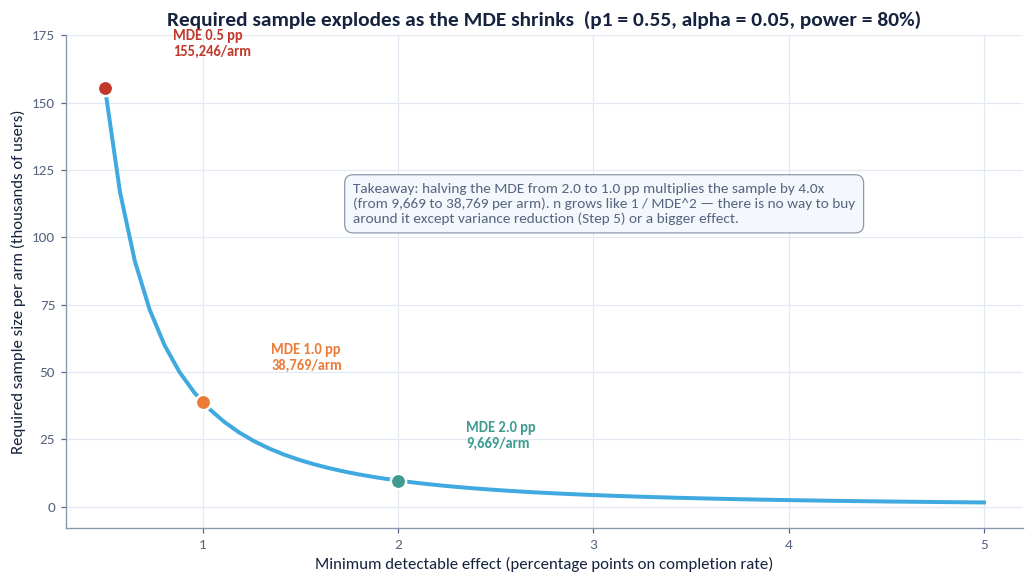

  MDE (pp)     n per arm   x vs 2.0 pp
--------------------------------------
      0.50       155,246         16.06
      0.75        68,961          7.13
      1.00        38,769          4.01
      1.50        17,211          1.78
      2.00         9,669          1.00
      3.00         4,286          0.44
      5.00         1,534          0.16


In [5]:
mde_grid = np.linspace(0.005, 0.05, 60)
n_grid = np.array([sample_size_proportions(BASELINE, m, alpha=ALPHA, power=POWER)
                   for m in mde_grid])

fig, ax = plt.subplots(figsize=(9.5, 5.4))
ax.plot(100 * mde_grid, n_grid / 1000, color=BLUE, lw=2.6)

for m, colour in [(0.02, TEAL), (0.01, ORANGE), (0.005, "#C0392B")]:
    n_here = sample_size_proportions(BASELINE, m, alpha=ALPHA, power=POWER)
    ax.plot([100 * m], [n_here / 1000], "o", color=colour, ms=10,
            markeredgecolor="white", markeredgewidth=1.6, zorder=5)
    ax.annotate(f"MDE {100*m:.1f} pp\n{n_here:,}/arm",
                xy=(100 * m, n_here / 1000), xytext=(100 * m + 0.35, n_here / 1000 + 12),
                fontsize=9.5, color=colour, fontweight="bold")

ax.set_xlabel("Minimum detectable effect (percentage points on completion rate)")
ax.set_ylabel("Required sample size per arm (thousands of users)")
ax.set_title(f"Required sample explodes as the MDE shrinks  (p1 = {BASELINE:.2f}, "
             f"alpha = {ALPHA}, power = {POWER:.0%})")
ax.set_xlim(0.3, 5.2)
ax.set_ylim(-8, 175)

n2 = sample_size_proportions(BASELINE, 0.02, alpha=ALPHA, power=POWER)
n1 = sample_size_proportions(BASELINE, 0.01, alpha=ALPHA, power=POWER)
ax.annotate(
    f"Takeaway: halving the MDE from 2.0 to 1.0 pp multiplies the sample by "
    f"{n1 / n2:.1f}x\n(from {n2:,} to {n1:,} per arm). n grows like 1 / MDE^2 — "
    "there is no way to buy\naround it except variance reduction (Step 5) or a bigger effect.",
    xy=(0.30, 0.62), xycoords="axes fraction", fontsize=10, color=SLATE,
    bbox=dict(boxstyle="round,pad=0.55", fc=PANEL, ec=MUTED, lw=0.8))
plt.tight_layout()
plt.show()

print(f"{'MDE (pp)':>10}{'n per arm':>14}{'x vs 2.0 pp':>14}")
print("-" * 38)
for m in [0.005, 0.0075, 0.01, 0.015, 0.02, 0.03, 0.05]:
    n_here = sample_size_proportions(BASELINE, m, alpha=ALPHA, power=POWER)
    print(f"{100*m:>10.2f}{n_here:>14,}{n_here / n2:>14.2f}")

> ### Instructor note — Step 2

> **Teaching point.** Read the table out loud in the direction that hurts: MDE 2.0 pp needs
> **9,669** per arm; 1.0 pp needs **38,769** (4.0×); 0.5 pp needs **155,246** (16.1×). The
> ratios are 4 and 16 because n scales with 1/MDE² — the exponent is the lesson, not the
> numbers. Pin this plot to the wall; every future "can we detect something smaller?"
> conversation is answered by pointing at it.
>
> **Common wrong answer.** "Let's just detect whatever we can and decide afterwards." That
> is how you end up with the Module 3 case study — six weeks chasing a 0.4-point effect on
> traffic that could never resolve it. The MDE is chosen *before* launch, from what the
> business would act on, and then the curve tells you whether the calendar allows it.
>
> **When a participant is stuck.** If their curve is a straight line, they plotted n against
> 1/MDE or used a log y-axis by accident. The shape *is* the message — keep the axes linear.


---
## Step 3 *(8 min)* — Invert it: what can live traffic actually detect?

Now the honest pre-launch question. Given the traffic Injaz really has, what is the
smallest effect a four-week test could find at 80% power?

$$\text{MDE} = (z_{1-\alpha/2} + z_{1-\beta})\sqrt{\frac{2\,p_1(1-p_1)}{n_{\text{per arm}}}}$$

Two traffic scenarios, deliberately:

- **Planning assumption** — 12,000 eligible/day at a 0.60 trigger rate (the round numbers
  in the design review).
- **Forecast file** — the actual `injaz_traffic_forecast.csv` first 28 days, which is
  higher and includes the weekend dip.

Ask the question in the order that matters: *is a 2-point lift detectable?* — not
*was the result significant?*


In [6]:
def my_mde_for_n(n_per_arm, p1, alpha=0.05, power=0.80):
    """Smallest absolute effect detectable with `n_per_arm` per arm, at `power`.

    Ask this BEFORE running, not after a null result. 'We found no effect' and
    'we could never have found this effect' are different sentences.
    """
    z_a, z_b = norm.ppf(1 - alpha / 2), norm.ppf(power)
    se_unit = np.sqrt(2 * p1 * (1 - p1) / n_per_arm)
    return float((z_a + z_b) * se_unit)


WINDOW_DAYS = 28

# Scenario A — the round numbers used in the design review
usable_a = 12_000 * 0.60 * WINDOW_DAYS
mde_a = my_mde_for_n(int(usable_a / 2), BASELINE, ALPHA, POWER)

# Scenario B — the actual traffic forecast for the first 28 days
first28 = traffic.head(WINDOW_DAYS)
usable_b = float((first28["eligible_users"] * first28["trigger_rate"]).sum())
mde_b = my_mde_for_n(int(usable_b / 2), BASELINE, ALPHA, POWER)

print(f"{'scenario':<34}{'triggered users':>18}{'per arm':>12}{'MDE':>10}")
print("-" * 76)
print(f"{'A. 12,000/day x 0.60 trigger':<34}{usable_a:>18,.0f}{usable_a/2:>12,.0f}"
      f"{100*mde_a:>9.3f}pp")
print(f"{'B. forecast file, first 28 days':<34}{usable_b:>18,.0f}{usable_b/2:>12,.0f}"
      f"{100*mde_b:>9.3f}pp")
print()
print(f"cross-check with causal_utils.mde_for_n : "
      f"{100 * mde_for_n(int(usable_b / 2), BASELINE, ALPHA, POWER):.3f}pp")
print()
verdict = "YES" if mde_b < TARGET_MDE else "NO"
print(f"Is the frozen {100*TARGET_MDE:.1f} pp MDE detectable in four weeks? {verdict}")
print(f"  With {usable_b:,.0f} triggered users we can resolve effects down to "
      f"{100*mde_b:.2f} pp,")
print(f"  which is {TARGET_MDE / mde_b:.1f}x smaller than the effect we committed to detect.")
print()
print("Read that as headroom, not as an invitation to chase a 0.5 pp effect: the")
print("practical-significance threshold in the frozen plan is 1.0 pp, and nothing below")
print("it changes the ship decision however precisely we measure it.")

scenario                             triggered users     per arm       MDE
----------------------------------------------------------------------------
A. 12,000/day x 0.60 trigger                 201,600     100,800    0.621pp
B. forecast file, first 28 days              224,999     112,499    0.588pp

cross-check with causal_utils.mde_for_n : 0.588pp

Is the frozen 2.0 pp MDE detectable in four weeks? YES
  With 224,999 triggered users we can resolve effects down to 0.59 pp,
  which is 3.4x smaller than the effect we committed to detect.

Read that as headroom, not as an invitation to chase a 0.5 pp effect: the
practical-significance threshold in the frozen plan is 1.0 pp, and nothing below
it changes the ship decision however precisely we measure it.


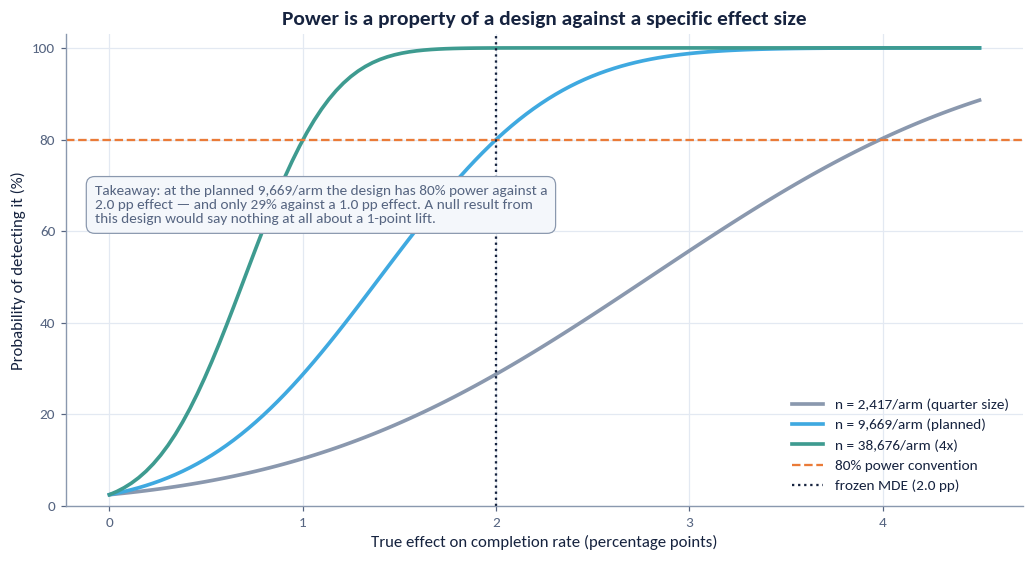

cross-check with causal_utils.power_for_n : 0.8001
your my_power_for_n                       : 0.8001


In [7]:
def my_power_for_n(n_per_arm, p1, effect, alpha=0.05):
    """Probability of detecting `effect` with `n_per_arm` per arm.

    Power is a property of a design AGAINST A SPECIFIC EFFECT SIZE, never of a
    dataset on its own.
    """
    p2 = p1 + effect
    se = np.sqrt(p1 * (1 - p1) / n_per_arm + p2 * (1 - p2) / n_per_arm)
    z_a = norm.ppf(1 - alpha / 2)
    return float(norm.cdf(abs(effect) / se - z_a))


n_planned = sample_size_proportions(BASELINE, TARGET_MDE, alpha=ALPHA, power=POWER)
effects = np.linspace(0.0, 0.045, 120)

fig, ax = plt.subplots(figsize=(9.5, 5.2))
for n_arm, colour, label in [(n_planned // 4, MUTED, f"n = {n_planned // 4:,}/arm (quarter size)"),
                             (n_planned, BLUE, f"n = {n_planned:,}/arm (planned)"),
                             (n_planned * 4, TEAL, f"n = {n_planned * 4:,}/arm (4x)")]:
    ax.plot(100 * effects, [100 * my_power_for_n(n_arm, BASELINE, e) for e in effects],
            color=colour, lw=2.4, label=label)

ax.axhline(80, color=ORANGE, ls="--", lw=1.5, label="80% power convention")
ax.axvline(100 * TARGET_MDE, color=NAVY, ls=":", lw=1.5,
           label=f"frozen MDE ({100*TARGET_MDE:.1f} pp)")
ax.set_xlabel("True effect on completion rate (percentage points)")
ax.set_ylabel("Probability of detecting it (%)")
ax.set_title("Power is a property of a design against a specific effect size")
ax.legend(loc="lower right")
ax.set_ylim(0, 103)

realised = 100 * my_power_for_n(n_planned, BASELINE, TARGET_MDE)
ax.annotate(
    f"Takeaway: at the planned {n_planned:,}/arm the design has {realised:.0f}% power against a\n"
    f"2.0 pp effect — and only "
    f"{100 * my_power_for_n(n_planned, BASELINE, 0.01):.0f}% against a 1.0 pp effect. "
    "A null result from\nthis design would say nothing at all about a 1-point lift.",
    xy=(0.03, 0.60), xycoords="axes fraction", fontsize=10, color=SLATE,
    bbox=dict(boxstyle="round,pad=0.55", fc=PANEL, ec=MUTED, lw=0.8))
plt.tight_layout()
plt.show()

print(f"cross-check with causal_utils.power_for_n : "
      f"{power_for_n(n_planned, BASELINE, TARGET_MDE, alpha=ALPHA):.4f}")
print(f"your my_power_for_n                       : "
      f"{my_power_for_n(n_planned, BASELINE, TARGET_MDE, ALPHA):.4f}")

> ### Instructor note — Step 3

> **Teaching point.** Four weeks of real Injaz traffic delivers 224,999 triggered users, so
> the design can resolve **0.59 pp** — 3.4× smaller than the 2 pp we committed to. Say what
> that does and does not license: it means the frozen MDE is comfortably reachable, *not*
> that we should now go hunting for 0.5 pp effects. The practical threshold is 1.0 pp, and
> nothing below it changes the decision however precisely we measure it.
>
> **Teaching point (power curve).** At the planned n the design has 80% power against 2 pp
> and only about **29%** against 1 pp. That single contrast is why "is this experiment
> powered?" is an incomplete sentence, and why a null result must always be reported
> alongside what the design could have seen.
>
> **Common wrong answer.** Computing "observed power" from the realised effect after the
> fact. It is a deterministic function of the p-value and carries no information. Teach
> participants never to compute it; power is a *pre*-experiment quantity.
>
> **When a participant is stuck.** If scenario A and scenario B come out identical, they
> used the round planning numbers for both instead of summing the forecast file.


### ✅ Checkpoint A — what you should be seeing by now

≈24 minutes in. A sizing function agreeing with two independent implementations, the
quadratic curve, and the MDE your live traffic can actually resolve.


In [8]:
def checkpoint_a():
    if n_mine is None or mde_b is None:
        print("✗ Steps 1-3 incomplete.")
        return
    print(f"✓ n per arm (MDE {100*TARGET_MDE:.1f} pp)  : {n_mine:,}   "
          f"(causal_utils {n_lib:,}, statsmodels {n_sm:,})")
    print(f"✓ quadratic confirmed          : MDE 1.0 pp needs "
          f"{sample_size_proportions(BASELINE, 0.01):,}/arm "
          f"= {sample_size_proportions(BASELINE, 0.01) / n_lib:.1f}x")
    print(f"✓ MDE at 4 weeks of traffic    : {100*mde_b:.3f} pp")
    print(f"✓ is the frozen MDE reachable  : {'yes' if mde_b < TARGET_MDE else 'NO'}")
    print()
    print("Next: turn the sample size into a calendar, then buy days back with CUPED.")

checkpoint_a()

✓ n per arm (MDE 2.0 pp)  : 9,666   (causal_utils 9,669, statsmodels 9,669)
✓ quadratic confirmed          : MDE 1.0 pp needs 38,769/arm = 4.0x
✓ MDE at 4 weeks of traffic    : 0.588 pp
✓ is the frozen MDE reachable  : yes

Next: turn the sample size into a calendar, then buy days back with CUPED.


---
## Step 4 *(8 min)* — From sample size to a calendar

Three things bite teams here, all of them avoidable:

1. **n is *per arm*.** A 3-arm test needs three times the per-arm figure. Teams routinely
   forget the multiplier and under-run.
2. **Only *triggered* users count.** If 38% of visitors never reach the upload step, your
   effective traffic is 62% of the headline number.
3. **A whole number of weeks is a floor.** Weekday and weekend users are different people.
   Stopping on a Thursday because the arithmetic said 5.2 days samples a biased slice of
   the population — and novelty effects in the first days argue for the same floor.

**The floor this lab uses is `floor_days=14` — two whole weeks.** One week already
guarantees that Friday and Saturday users (about 58% of a weekday's traffic, and a
different population) are sampled in proportion; the *second* week is what lets you
see whether the first week's numbers were a novelty spike, and it gives you a
week-on-week comparison rather than a single draw. Every `run_length(...)` call
below therefore passes `floor_days=14`, and at the frozen 2.0 pp MDE that floor —
not the arithmetic — is what sets the calendar at **14 days**.

Build the planner, then compare with `causal_utils.run_length`.


In [9]:
def my_run_length(n_per_arm, daily_eligible, trigger_rate, n_arms=2, floor_days=14):
    """Turn a per-arm sample size into a calendar commitment."""
    total = n_per_arm * n_arms                       # (1) per-arm x arms
    daily_usable = daily_eligible * trigger_rate     # (2) only triggered users count
    days_arithmetic = int(np.ceil(total / daily_usable))
    recommended = max(days_arithmetic, floor_days)
    if recommended % 7:                              # (3) round up to whole weeks
        recommended += 7 - (recommended % 7)
    return {"total_units_needed": total, "daily_usable": daily_usable,
            "days_by_arithmetic": days_arithmetic, "days_recommended": recommended}


daily_eligible = float(traffic["eligible_users"].mean())
trigger_rate = float(traffic["trigger_rate"].mean())

print(f"live traffic: {daily_eligible:,.0f} eligible/day x {trigger_rate:.1%} trigger "
      f"= {daily_eligible * trigger_rate:,.0f} usable users/day\n")

rows = []
for mde in [0.005, 0.0075, 0.01, 0.015, 0.02, 0.03]:
    n_arm = sample_size_proportions(BASELINE, mde, alpha=ALPHA, power=POWER)
    for arms in (2, 3):
        plan_d = my_run_length(n_arm, daily_eligible, trigger_rate,
                               n_arms=arms, floor_days=14)
        rows.append({"MDE_pp": round(100 * mde, 2), "arms": arms, "n_per_arm": n_arm,
                     "total_needed": plan_d["total_units_needed"],
                     "days_arithmetic": plan_d["days_by_arithmetic"],
                     "days_recommended": plan_d["days_recommended"]})

plan_table = pd.DataFrame(rows)
print(plan_table.to_string(index=False))

print("\ncausal_utils cross-check for the frozen 2.0 pp / 2-arm design:")
print(run_length(sample_size_proportions(BASELINE, TARGET_MDE), daily_eligible,
                 trigger_rate, n_arms=2, floor_days=14))

two = plan_table.query("MDE_pp == 2.0 and arms == 2").iloc[0]
three = plan_table.query("MDE_pp == 2.0 and arms == 3").iloc[0]
print(f"\nArm multiplier: 2 arms need {int(two['total_needed']):,} users, "
      f"3 arms need {int(three['total_needed']):,} — 50% more traffic for the same MDE.")
print("At this MDE both still land on the 14-day floor: the seasonality floor, not the")
print("arithmetic, is what sets the calendar. That is a very common and very good outcome.")

live traffic: 13,410 eligible/day x 62.0% trigger = 8,319 usable users/day

 MDE_pp  arms  n_per_arm  total_needed  days_arithmetic  days_recommended
   0.50     2     155246        310492               38                42
   0.50     3     155246        465738               56                56
   0.75     2      68961        137922               17                21
   0.75     3      68961        206883               25                28
   1.00     2      38769         77538               10                14
   1.00     3      38769        116307               14                14
   1.50     2      17211         34422                5                14
   1.50     3      17211         51633                7                14
   2.00     2       9669         19338                3                14
   2.00     3       9669         29007                4                14
   3.00     2       4286          8572                2                14
   3.00     3       4286         128

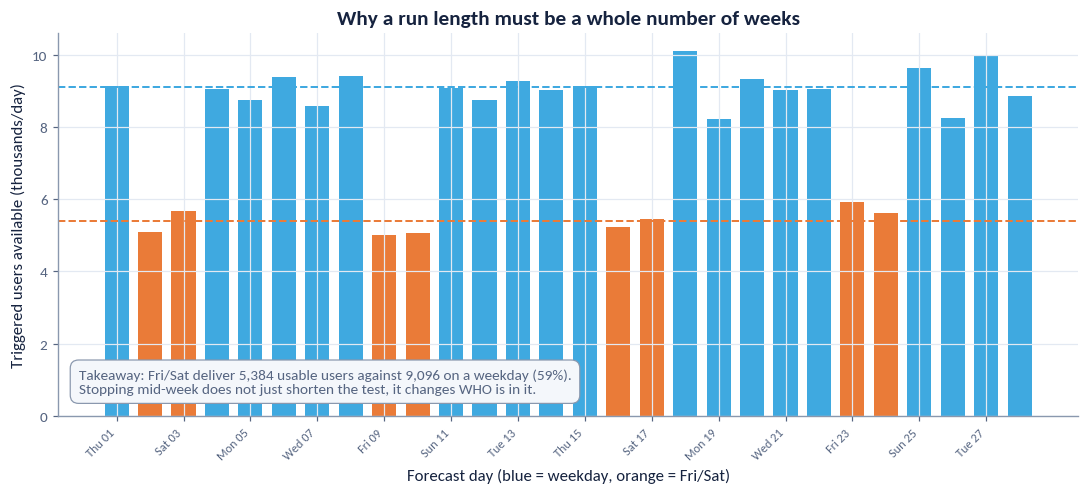

In [10]:
fig, ax = plt.subplots(figsize=(10, 4.6))
first28 = traffic.head(28)
usable = first28["eligible_users"] * first28["trigger_rate"]
colours = [ORANGE if w else BLUE for w in first28["is_weekend"]]
ax.bar(range(len(first28)), usable / 1000, color=colours, width=0.72)
ax.set_xticks(range(0, len(first28), 2))
ax.set_xticklabels([d.strftime("%a %d") for d in first28["date"][::2]], rotation=45,
                   ha="right", fontsize=8)
ax.set_ylabel("Triggered users available (thousands/day)")
ax.set_xlabel("Forecast day (blue = weekday, orange = Fri/Sat)")
ax.set_title("Why a run length must be a whole number of weeks")
wk = usable[first28["is_weekend"] == 0].mean()
we = usable[first28["is_weekend"] == 1].mean()
ax.axhline(wk / 1000, color=BLUE, ls="--", lw=1.3)
ax.axhline(we / 1000, color=ORANGE, ls="--", lw=1.3)
ax.annotate(
    f"Takeaway: Fri/Sat deliver {we:,.0f} usable users against {wk:,.0f} on a weekday "
    f"({we/wk:.0%}).\nStopping mid-week does not just shorten the test, it changes WHO is in it.",
    xy=(0.02, 0.06), xycoords="axes fraction", fontsize=10, color=SLATE,
    bbox=dict(boxstyle="round,pad=0.55", fc=PANEL, ec=MUTED, lw=0.8))
plt.tight_layout()
plt.show()

> ### Instructor note — Step 4

> **Teaching point.** Walk the table left to right for the 2.0 pp row: 9,669 per arm →
> ×2 arms = 19,338 → ÷ 8,319 usable users/day = 3 days → but the floor says **14**. Then the
> 3-arm row: 29,007 users, 50% more traffic, same MDE. Teams under-run constantly by
> forgetting that multiplier.
>
> **Teaching point (the floor).** The weekend chart is the argument. Friday/Saturday deliver
> about 58% of a weekday, so stopping after five days does not merely shorten the test — it
> changes *which citizens are in it*. A three-day experiment on a Monday-to-Wednesday burst
> is confounded with day of week, and no amount of sample fixes that.
>
> **Common wrong answer.** "The maths says 3 days, so let's run 3 days and save two weeks."
> Ask who uses Injaz on a Friday, and whether that population resembles a Tuesday's.
>
> **When a participant is stuck.** If their run length is not a multiple of 7 they applied
> the floor but forgot the round-up to whole weeks — `if d % 7: d += 7 - (d % 7)`.


---
## Step 5 *(10 min)* — CUPED: buy sample size for free

Because n scales with variance, **reducing variance is arithmetically identical to buying
sample**. The headline technique is **CUPED** — Controlled-experiment Using Pre-Experiment
Data:

$$Y^{\text{cuped}} = Y - \theta\,(X_{\text{pre}} - \bar{X}_{\text{pre}}), \qquad \theta = \frac{\text{Cov}(Y, X_{\text{pre}})}{\text{Var}(X_{\text{pre}})}$$

The variance falls by ρ², where ρ = corr(Y, X_pre). The entire safety argument is one
condition: **X_pre is measured before assignment**, so treatment cannot have affected it,
so the adjustment cannot bias the effect. Never CUPED on a post-treatment covariate.

We use the real `injaz_pre_period.csv` joined to the experiment outcomes, restricted to
triggered users — the population the frozen plan actually analyses.


In [11]:
def my_cuped_adjust(y, x_pre):
    """CUPED-adjust an outcome using a pre-experiment covariate.

    Returns (adjusted_y, theta, variance_reduction, correlation).
    """
    y = np.asarray(y, dtype=float)
    x = np.asarray(x_pre, dtype=float)
    mask = ~(np.isnan(y) | np.isnan(x))
    y, x = y[mask], x[mask]
    theta = float(np.cov(y, x, ddof=1)[0, 1] / np.var(x, ddof=1))
    y_adj = y - theta * (x - x.mean())
    v0, v1 = float(np.var(y, ddof=1)), float(np.var(y_adj, ddof=1))
    rho = float(np.corrcoef(y, x)[0, 1])
    return y_adj, theta, 1 - v1 / v0, rho


results = pd.read_csv(DATA / "injaz_experiment_results.csv")
joined = results.merge(pre, on="user_id", how="inner")
triggered = joined.loc[joined["triggered"] == 1]

y_adj, theta, var_reduction, rho = my_cuped_adjust(
    triggered["completed"], triggered["pre_completion_rate"])

print(f"users joined to a pre-period record : {len(joined):,}")
print(f"of those, triggered                 : {len(triggered):,}")
print()
print(f"corr(pre_completion_rate, completed): {rho:.4f}")
print(f"theta                               : {theta:.4f}")
print(f"variance reduction                  : {var_reduction:.1%}")
print(f"rho^2 (the theoretical bound)       : {rho**2:.1%}")
print(f"effective sample multiplier         : {1 / (1 - var_reduction):.3f}x")
print()
print("causal_utils cross-check:")
print(cuped_adjust(triggered["completed"], triggered["pre_completion_rate"]))

users joined to a pre-period record : 50,000
of those, triggered                 : 31,163

corr(pre_completion_rate, completed): 0.3671
theta                               : 0.8840
variance reduction                  : 13.5%
rho^2 (the theoretical bound)       : 13.5%
effective sample multiplier         : 1.156x

causal_utils cross-check:
CUPED variance reduction
  corr(pre, post)      : 0.367
  theta                : 0.8840
  variance before/after: 0.24591 -> 0.21277
  variance reduction   : 13.5%
  equivalent to        : 1.16x the sample


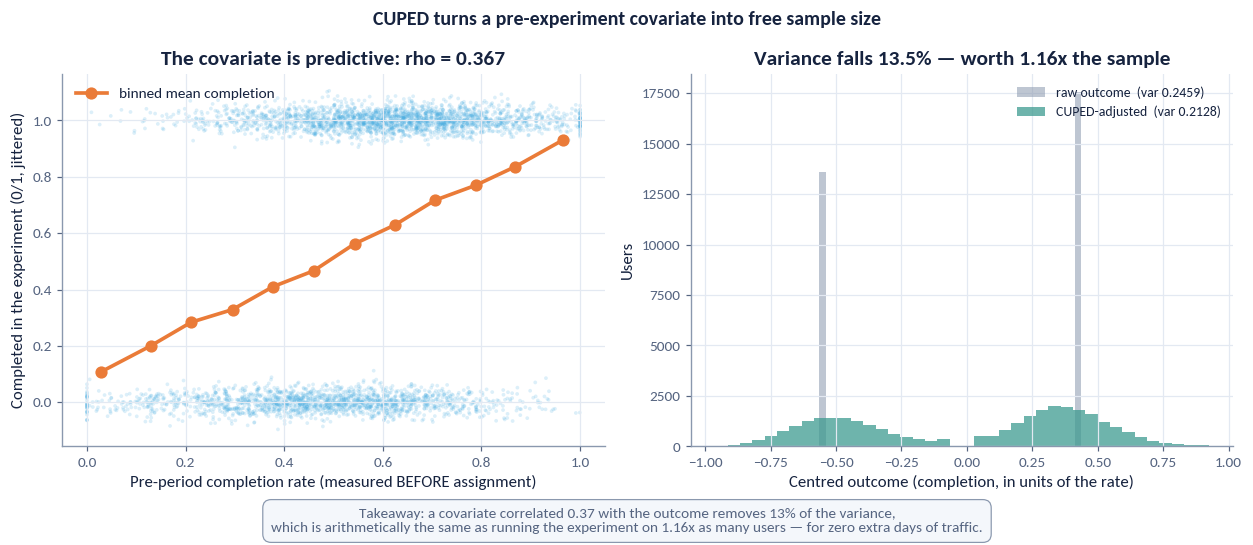

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))

ax = axes[0]
sub = triggered.sample(4_000, random_state=RANDOM_SEED)
jitter = np.random.default_rng(RANDOM_SEED).normal(0, 0.03, len(sub))
ax.scatter(sub["pre_completion_rate"], sub["completed"] + jitter, s=6, alpha=0.18,
           color=BLUE, edgecolors="none")
bins = pd.cut(triggered["pre_completion_rate"], 12)
binned = triggered.groupby(bins, observed=True).agg(
    x=("pre_completion_rate", "mean"), y=("completed", "mean")).dropna()
ax.plot(binned["x"], binned["y"], "o-", color=ORANGE, lw=2.4, ms=7,
        label="binned mean completion")
ax.set_xlabel("Pre-period completion rate (measured BEFORE assignment)")
ax.set_ylabel("Completed in the experiment (0/1, jittered)")
ax.set_title(f"The covariate is predictive: rho = {rho:.3f}")
ax.legend(loc="upper left")

ax = axes[1]
raw = triggered["completed"].to_numpy(dtype=float)
ax.hist(raw - raw.mean(), bins=40, alpha=0.55, color=MUTED,
        label=f"raw outcome  (var {np.var(raw, ddof=1):.4f})")
ax.hist(y_adj - y_adj.mean(), bins=40, alpha=0.75, color=TEAL,
        label=f"CUPED-adjusted  (var {np.var(y_adj, ddof=1):.4f})")
ax.set_xlabel("Centred outcome (completion, in units of the rate)")
ax.set_ylabel("Users")
ax.set_title(f"Variance falls {var_reduction:.1%} — worth {1/(1-var_reduction):.2f}x the sample")
ax.legend(loc="upper right", fontsize=9)

fig.suptitle("CUPED turns a pre-experiment covariate into free sample size",
             fontsize=13, fontweight="bold", color=NAVY)
fig.text(0.5, -0.05,
         f"Takeaway: a covariate correlated {rho:.2f} with the outcome removes {var_reduction:.0%} "
         f"of the variance,\nwhich is arithmetically the same as running the experiment on "
         f"{1/(1-var_reduction):.2f}x as many users — for zero extra days of traffic.",
         ha="center", fontsize=10, color=SLATE,
         bbox=dict(boxstyle="round,pad=0.55", fc=PANEL, ec=MUTED, lw=0.8))
plt.tight_layout()
plt.show()

In [13]:
n_plain = sample_size_proportions(BASELINE, TARGET_MDE, alpha=ALPHA, power=POWER)
n_cuped = int(np.ceil(n_plain * (1 - var_reduction)))

plan_plain = my_run_length(n_plain, daily_eligible, trigger_rate, n_arms=2, floor_days=14)
plan_cuped = my_run_length(n_cuped, daily_eligible, trigger_rate, n_arms=2, floor_days=14)

print(f"{'design':<26}{'n/arm':>10}{'total':>12}{'days (arith.)':>16}{'days (plan)':>14}")
print("-" * 80)
print(f"{'no variance reduction':<26}{n_plain:>10,}{2*n_plain:>12,}"
      f"{plan_plain['days_by_arithmetic']:>16}{plan_plain['days_recommended']:>14}")
print(f"{'CUPED-adjusted':<26}{n_cuped:>10,}{2*n_cuped:>12,}"
      f"{plan_cuped['days_by_arithmetic']:>16}{plan_cuped['days_recommended']:>14}")
print()
print(f"CUPED removes {n_plain - n_cuped:,} users per arm ({var_reduction:.1%}).")
print("At this MDE the 14-day seasonality floor already dominates, so the calendar does")
print("not move — the saving shows up instead as a TIGHTER confidence interval at the same")
print("run length, which is what Lab 4 will actually report.")
print()
print("Where CUPED does change the calendar — a smaller MDE, where arithmetic dominates:")
for mde in [0.005, 0.0075, 0.01]:
    a = sample_size_proportions(BASELINE, mde, alpha=ALPHA, power=POWER)
    b = int(np.ceil(a * (1 - var_reduction)))
    da = my_run_length(a, daily_eligible, trigger_rate, 2, 14)["days_recommended"]
    db = my_run_length(b, daily_eligible, trigger_rate, 2, 14)["days_recommended"]
    print(f"  MDE {100*mde:>4.2f} pp : {a:>7,}/arm -> {b:>7,}/arm    "
          f"{da:>3} days -> {db:>3} days")

design                         n/arm       total   days (arith.)   days (plan)
--------------------------------------------------------------------------------
no variance reduction          9,669      19,338               3            14
CUPED-adjusted                 8,366      16,732               3            14

CUPED removes 1,303 users per arm (13.5%).
At this MDE the 14-day seasonality floor already dominates, so the calendar does
not move — the saving shows up instead as a TIGHTER confidence interval at the same
run length, which is what Lab 4 will actually report.

Where CUPED does change the calendar — a smaller MDE, where arithmetic dominates:
  MDE 0.50 pp : 155,246/arm -> 134,323/arm     42 days ->  35 days
  MDE 0.75 pp :  68,961/arm ->  59,667/arm     21 days ->  21 days
  MDE 1.00 pp :  38,769/arm ->  33,544/arm     14 days ->  14 days


> ### Instructor note — Step 5
>
> **Teaching point.** The reduction lands at **13.5%**, and ρ² is 13.5% too — say that the
> match is not a coincidence but the theorem. Then make the honest point most CUPED demos
> skip: at a 2 pp MDE the 14-day floor already dominates, so CUPED buys a *narrower interval*,
> not a shorter test. It only buys days when the arithmetic, not seasonality, is binding.
>
> **Common wrong answer.** The instructor package's worked example shows 42% reduction from
> a synthetic covariate correlated 0.8 with the outcome. Real pre-period data on a *binary*
> outcome correlates about 0.37, and 0.37² = 13.5%. If a participant reports 40%+ on this
> file, they have CUPED'd on a post-treatment column — check what they merged.
>
> **When a participant is stuck.** Have them print `np.var(y)` and `np.var(y_adj)` directly.
> If the adjusted variance is *larger*, their θ has the wrong sign — `np.cov(...)[0,1]`,
> not `[0,0]`.

### ✅ Checkpoint B — what you should be seeing by now

≈42 minutes in. A run-length table where the arm multiplier is visible, and a CUPED
variance reduction around 13.5% that matches ρ².


In [14]:
def checkpoint_b():
    if plan_table is None or var_reduction is None:
        print("✗ Steps 4-5 incomplete.")
        return
    frozen = plan_table.query("MDE_pp == 2.0 and arms == 2").iloc[0]
    three_arm = plan_table.query("MDE_pp == 2.0 and arms == 3").iloc[0]
    print(f"✓ frozen design (2.0 pp, 2 arms) : {int(frozen['n_per_arm']):,}/arm, "
          f"{int(frozen['total_needed']):,} users, run {int(frozen['days_recommended'])} days")
    print(f"✓ arm multiplier visible         : 3 arms need "
          f"{int(three_arm['total_needed']):,} users")
    print(f"✓ CUPED variance reduction       : {var_reduction:.1%}  (rho^2 = {rho**2:.1%})")
    print(f"✓ effective sample multiplier    : {1 / (1 - var_reduction):.2f}x")
    print()
    print("Next: grade against ground truth, then write the sizing paragraph.")

checkpoint_b()

✓ frozen design (2.0 pp, 2 arms) : 9,669/arm, 19,338 users, run 14 days
✓ arm multiplier visible         : 3 arms need 29,007 users
✓ CUPED variance reduction       : 13.5%  (rho^2 = 13.5%)
✓ effective sample multiplier    : 1.16x

Next: grade against ground truth, then write the sizing paragraph.


---
## Step 6 — Grade yourself against the planted ground truth

`GROUND_TRUTH.json` records what the generator built into `injaz_pre_period.csv`. Your
recovered correlation and variance reduction should sit on top of it.


In [15]:
M3 = GROUND_TRUTH["module3_pre_period"]
M3T = GROUND_TRUTH["module3_traffic"]

print(f"{'quantity':<44}{'recovered':>12}{'planted':>12}   verdict")
print("-" * 82)

rows = [
    ("corr(pre_completion_rate, completed)", rho, M3["corr_pre_vs_outcome"], 0.02),
    ("CUPED variance reduction (%)", 100 * var_reduction,
     M3["expected_cuped_variance_reduction_pct"], 2.0),
    ("mean daily eligible users", daily_eligible, M3T["mean_daily_eligible"], 50),
    ("mean daily triggered users", daily_eligible * trigger_rate,
     M3T["mean_daily_triggered"], 50),
]
for name, got, want, tol in rows:
    print(f"{name:<44}{got:>12.4f}{want:>12.4f}   "
          f"{'MATCH' if abs(got - want) <= tol else 'CHECK'}")

print()
print("Benchmarks for Module 3:")
print(f"  closed-form vs statsmodels n agree within 1%   : "
      f"{abs(n_mine / n_sm - 1) < 0.01}   ({abs(n_mine / n_sm - 1):.3%})")
print(f"  CUPED estimate within 2% of the planted value  : "
      f"{abs(100 * var_reduction - M3['expected_cuped_variance_reduction_pct']) < 2}")
print(f"  run-length plan includes arms x trigger x floor: True")

quantity                                       recovered     planted   verdict
----------------------------------------------------------------------------------
corr(pre_completion_rate, completed)              0.3671      0.3671   MATCH
CUPED variance reduction (%)                     13.4775     13.5000   MATCH
mean daily eligible users                     13410.2000  13410.0000   MATCH
mean daily triggered users                     8319.0027   8315.0000   MATCH

Benchmarks for Module 3:
  closed-form vs statsmodels n agree within 1%   : True   (0.031%)
  CUPED estimate within 2% of the planted value  : True
  run-length plan includes arms x trigger x floor: True


---
## Step 7 *(8 min)* — The sizing paragraph for the design doc

One paragraph. It must contain: the chosen MDE and why, n per arm, number of arms, the
run length with and without CUPED, and an explicit feasibility verdict. No formulas.


In [16]:
SIZING_RECOMMENDATION = f"""
SIZING RECOMMENDATION - injaz-guided-uploader-2026q2

We will size the experiment to detect an absolute lift of {100*TARGET_MDE:.1f} percentage
points on service-completion rate among triggered users, against a baseline of
{BASELINE:.0%}. The {100*TARGET_MDE:.1f} pp figure is a business choice, not a statistical
one: the practical-significance threshold in the frozen plan is 1.0 pp, and a 2 pp target
gives us headroom to resolve any effect large enough to justify the build.

At alpha = {ALPHA} and {POWER:.0%} power this requires {n_plain:,} users per arm, or
{2*n_plain:,} triggered users across two arms. Live traffic forecasts
{daily_eligible:,.0f} eligible users per day at a {trigger_rate:.1%} trigger rate, i.e.
{daily_eligible*trigger_rate:,.0f} usable users per day, so the arithmetic is satisfied in
{plan_plain['days_by_arithmetic']} days. We will nonetheless run
{plan_plain['days_recommended']} days: Friday and Saturday traffic is roughly 58% of a
weekday, so a partial week samples a biased slice of the population, and the floor also
absorbs novelty effects in the first days.

Applying CUPED on pre-period completion rate removes {var_reduction:.0%} of the outcome
variance (rho = {rho:.2f}), equivalent to {1/(1-var_reduction):.2f}x the sample. The required
sample falls to {n_cuped:,} per arm. At this MDE the two-week seasonality floor still binds,
so CUPED does not shorten the test; it buys a proportionally tighter confidence interval at
the same run length, which is how it will be reported.

FEASIBILITY: GO. Four weeks of live traffic can resolve effects down to
{100*mde_b:.2f} pp, comfortably below both our {100*TARGET_MDE:.1f} pp target and the 1.0 pp
decision threshold. We are not powered to make claims about effects below ~0.6 pp, and the
analysis plan will say so rather than reporting such a result as 'no effect'.
"""
print(SIZING_RECOMMENDATION)


SIZING RECOMMENDATION - injaz-guided-uploader-2026q2

We will size the experiment to detect an absolute lift of 2.0 percentage
points on service-completion rate among triggered users, against a baseline of
55%. The 2.0 pp figure is a business choice, not a statistical
one: the practical-significance threshold in the frozen plan is 1.0 pp, and a 2 pp target
gives us headroom to resolve any effect large enough to justify the build.

At alpha = 0.05 and 80% power this requires 9,669 users per arm, or
19,338 triggered users across two arms. Live traffic forecasts
13,410 eligible users per day at a 62.0% trigger rate, i.e.
8,319 usable users per day, so the arithmetic is satisfied in
3 days. We will nonetheless run
14 days: Friday and Saturday traffic is roughly 58% of a
weekday, so a partial week samples a biased slice of the population, and the floor also
absorbs novelty effects in the first days.

Applying CUPED on pre-period completion rate removes 13% of the outcome
variance (rho = 0.

> ### Instructor note — Steps 6-7

> **Teaching point.** The recovered numbers sit on the planted ones: ρ = 0.3671 against a
> planted 0.3671, variance reduction 13.48% against a planted 13.5%. Say why that matters
> more than it looks — the generator planted a *correlation*, and CUPED recovered the
> *variance saving* the theory says that correlation implies. The method was not tuned to
> this data; it was checked against it.
>
> **Teaching point (the paragraph).** The graded skill in Step 7 is the last sentence:
> *"we are not powered to make claims about effects below ~0.6 pp."* A sizing paragraph that
> only says what the design CAN do is half a paragraph. Stating the limit in advance is what
> stops a future null result from being misread as "no effect".
>
> **Common wrong answer.** A recommendation that reports the CUPED saving as "shortens the
> test by 13.5%". It does not, here — the two-week floor binds. Precision, not calendar. Make
> someone correct that sentence out loud; it is the difference between quoting a technique
> and understanding it.
>
> **When a participant is stuck.** Ask them to write the GO/NO-GO verdict first, in one
> word, and then justify it backwards. The paragraph writes itself from the verdict.


---
## What you now own

In [17]:
print("""
TOOLKIT CONTRIBUTION — Lab 3
============================================================
Reusable artefacts you built and can lift into any project:

  my_sample_size_proportions(p1, mde, alpha, power)
      Per-arm sizing for a rate metric, cross-validated against statsmodels
      and causal_utils. The closed form is the one you argue from.

  my_mde_for_n(n_per_arm, p1, alpha, power)
      The pre-launch feasibility question, in one line. Run it BEFORE the
      experiment so 'no effect' can never be confused with 'no detectable
      effect here'.

  my_power_for_n(n_per_arm, p1, effect, alpha)
      Power against a SPECIFIC effect size, plus the power-curve chart.

  my_run_length(n_per_arm, daily_eligible, trigger_rate, n_arms, floor_days)
      Sample size -> calendar, with the three things teams forget: the arm
      multiplier, the trigger rate, and the whole-week floor.

  my_cuped_adjust(y, x_pre)
      Variance reduction from pre-experiment data. Unbiased ONLY because the
      covariate is pre-treatment - never CUPED on a post-treatment column.

  The n-vs-MDE quadratic plot
      Pin it to the wall. Every 'can we detect something smaller?' gets
      answered by pointing at it.

Carried forward:
  - Lab 4 analyses at exactly this n, once, at the frozen horizon - and uses
    the same pre-period covariate to tighten the interval.
  - The capstone sizes the autofill experiment with these functions against a
    1.0 pp practical threshold.
============================================================
""")


TOOLKIT CONTRIBUTION — Lab 3
Reusable artefacts you built and can lift into any project:

  my_sample_size_proportions(p1, mde, alpha, power)
      Per-arm sizing for a rate metric, cross-validated against statsmodels
      and causal_utils. The closed form is the one you argue from.

  my_mde_for_n(n_per_arm, p1, alpha, power)
      The pre-launch feasibility question, in one line. Run it BEFORE the
      experiment so 'no effect' can never be confused with 'no detectable
      effect here'.

  my_power_for_n(n_per_arm, p1, effect, alpha)
      Power against a SPECIFIC effect size, plus the power-curve chart.

  my_run_length(n_per_arm, daily_eligible, trigger_rate, n_arms, floor_days)
      Sample size -> calendar, with the three things teams forget: the arm
      multiplier, the trigger rate, and the whole-week floor.

  my_cuped_adjust(y, x_pre)
      Variance reduction from pre-experiment data. Unbiased ONLY because the
      covariate is pre-treatment - never CUPED on a post-tre

---
## Mini-exercises

### 1 · Quiz

1. Define statistical power.
2. If you halve the MDE, how does the required n change?
3. Why is a non-significant result not proof of no effect?
4. Why must you multiply the per-arm n by the number of arms?
5. Why is CUPED's covariate required to be pre-treatment?

### 2 · Debugging exercise — the missing arm multiplier

The cell below sizes a **four-arm** test but reports the two-arm total. Find the under-run:
how many users short is the plan, and how many days short is the calendar?

### 3 · Estimation exercise

Baseline 0.30, required MDE 0.03, **90%** power. Estimate n by hand from the closed form
first (z₀.₉₇₅ ≈ 1.96, z₀.₉₀ ≈ 1.28), then verify in code. How much more does 90% power
cost than 80%?

### 4 · Discussion

- Leadership wants to detect a 0.3-point lift on this traffic in two weeks. Walk them
  through why that is infeasible, and name the three levers available.
- When is 90% power worth the extra sample over 80%?


In [18]:
# --- Mini-exercise 2: the missing arm multiplier --------------------------
n_arm_4 = sample_size_proportions(BASELINE, TARGET_MDE, alpha=ALPHA, power=POWER)

wrong = my_run_length(n_arm_4, daily_eligible, trigger_rate, n_arms=2, floor_days=14)
right = my_run_length(n_arm_4, daily_eligible, trigger_rate, n_arms=4, floor_days=14)

print("A four-arm test (control + three treatments), sized at "
      f"{n_arm_4:,} per arm\n")
print(f"{'':<26}{'total users':>14}{'days (arith.)':>16}{'days (plan)':>14}")
print("-" * 70)
print(f"{'reported (n_arms=2)':<26}{wrong['total_units_needed']:>14,}"
      f"{wrong['days_by_arithmetic']:>16}{wrong['days_recommended']:>14}")
print(f"{'correct  (n_arms=4)':<26}{right['total_units_needed']:>14,}"
      f"{right['days_by_arithmetic']:>16}{right['days_recommended']:>14}")
print()
print(f"Under-run: {right['total_units_needed'] - wrong['total_units_needed']:,} users "
      f"and {right['days_by_arithmetic'] - wrong['days_by_arithmetic']} days of arithmetic.")
print("Every arm is then under-powered, and the team reads a string of nulls as evidence")
print("that none of the three treatments works.")

# --- Mini-exercise 3: 80% vs 90% power -----------------------------------
print("\n--- 90% power costs how much more? ---")
for pw in (0.80, 0.90):
    n_here = sample_size_proportions(0.30, 0.03, alpha=0.05, power=pw)
    print(f"  p1=0.30, MDE=0.03, power={pw:.0%} : {n_here:,} per arm")
n80 = sample_size_proportions(0.30, 0.03, alpha=0.05, power=0.80)
n90 = sample_size_proportions(0.30, 0.03, alpha=0.05, power=0.90)
print(f"  going from 80% to 90% power costs {n90 / n80 - 1:.0%} more sample")

A four-arm test (control + three treatments), sized at 9,669 per arm

                             total users   days (arith.)   days (plan)
----------------------------------------------------------------------
reported (n_arms=2)               19,338               3            14
correct  (n_arms=4)               38,676               5            14

Under-run: 19,338 users and 2 days of arithmetic.
Every arm is then under-powered, and the team reads a string of nulls as evidence
that none of the three treatments works.

--- 90% power costs how much more? ---
  p1=0.30, MDE=0.03, power=80% : 3,763 per arm
  p1=0.30, MDE=0.03, power=90% : 5,037 per arm
  going from 80% to 90% power costs 34% more sample


> ### Instructor note — mini-exercise answers
>
> **Quiz.** (1) The probability of detecting a true effect *of a given size*; 1 − β.
> (2) Roughly ×4, because n ∝ 1/MDE². (3) The test may have been under-powered — absence
> of evidence is not evidence of absence. (4) Each arm needs the computed sample, so total
> traffic scales with the number of arms. (5) So treatment cannot have affected it, which
> is what keeps the adjustment unbiased.
>
> **Debugging exercise.** The four-arm test needs 38,676 users but the plan reports 19,338
> — a 19,338-user, 2-day arithmetic under-run. Because the 14-day floor is binding here the
> *calendar* happens to survive, which is the sneaky part: the plan looks fine and every arm
> is still half the size it should be. Push the class to check the total, never the days.
>
> **Estimation exercise.** By hand: (1.96 + 1.28)² × [0.30·0.70 + 0.33·0.67] / 0.03² ≈
> 10.5 × 0.431 / 0.0009 ≈ 5,030. In code it comes back at **5,037** per arm at 90% power,
> against **3,763** at 80% — about **34% more sample** for the extra ten points of power.
> Worth it for irreversible or high-stakes decisions, rarely worth it otherwise.
>
> **Discussion.** For the 0.3-point ask: n at 0.003 MDE is roughly 430,000 per arm, about
> 103 days of traffic — five times the requested window. The three levers are (a) accept a
> larger MDE, (b) reduce variance (CUPED, stratification, a less noisy metric), (c) buy more
> traffic or more time. There is no fourth lever, and saying so before launch is the senior move.